# HydroSense-Kenya Problem Statement

Agriculture remains one of the most important sectors in Kenya and across Africa. However, many farms continue to face challenges related to water scarcity, unpredictable rainfall patterns, increasing temperatures, and inefficient irrigation practices. Climate variability has made it more difficult for farmers to determine when and how much water should be applied to crops. Over-irrigation wastes water and energy, while under-irrigation can lead to moisture stress, reduced crop growth, and lower yields. As water resources become increasingly limited, there is a growing need for intelligent systems that support efficient water management.

The HydroSense-Kenya project aims to address this challenge through the development of a scientific computing system that combines weather information, soil sensor measurements, and crop-specific parameters to support irrigation decision-making. The project uses computational models to estimate soil moisture conditions, calculate water losses, simulate future moisture levels, and recommend irrigation actions that maintain healthy crop growth while minimizing water consumption.

The system is based on the concept of water balance. Soil moisture changes over time depending on several factors, including rainfall, irrigation, evapotranspiration, and drainage. Rainfall and irrigation increase the amount of water available in the soil, while evapotranspiration and drainage reduce it. By representing these processes mathematically, it becomes possible to estimate current and future soil moisture levels and identify situations where crops may experience water stress.

The project uses three datasets. The weather dataset contains measurements such as rainfall, temperature, humidity, wind speed, and solar radiation indicators. These variables influence evapotranspiration, which represents water lost from the soil and plant surfaces. The soil sensor dataset contains measurements from multiple farm zones, including soil moisture, tank levels, pump flow rates, and pump power consumption. The crop parameter dataset provides crop-specific information such as target moisture levels, field capacity, and drainage coefficients. Together, these datasets provide the information required to model the water status of the farm.

Scientific computing techniques will be applied throughout the project. Python will be used to process and analyze data, implement numerical methods, perform simulations, and generate visualizations. Mathematical models will be used to estimate evapotranspiration and soil-water balance. Numerical methods such as root finding, numerical differentiation, numerical integration, and differential equation solvers will later be applied to support decision making. Monte Carlo simulation will also be used to study uncertainty in rainfall and irrigation demand.

The central scientific question addressed by this project is: “Given weather and soil sensor data, how can water availability be modelled, water deficits estimated, future soil moisture simulated, and efficient irrigation recommendations generated while minimizing water use and avoiding crop moisture stress?” Answering this question requires the integration of data analysis, mathematical modelling, numerical computation, and scientific interpretation.

Ultimately, HydroSense-Kenya seeks to demonstrate how scientific computing can support sustainable agriculture by transforming raw environmental data into practical irrigation recommendations. The resulting system provides a computational framework for improving water-use efficiency, reducing unnecessary irrigation, and supporting climate-aware agricultural decision making.


# Task 2: Dataset Loading and Initial Inspection

The purpose of this section is to load the provided HydroSense-Kenya datasets and perform an initial inspection of their structure, dimensions, data types, and potential data quality issues.

In [6]:
#imports.
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
#loading the weather, soil, and params datasets.

weather = pd.read_csv("../data/raw/weather_daily.csv",na_values=["NA",""])
soil = pd.read_csv("../data/raw/soil_sensor_data.csv",na_values=["NA",""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv",na_values=["NA",""])

#Inspecting the structure of the weather, soil and params datasets.

print("\nWeather DataFrame Information.\n")
print(f"Shape : {weather.shape}")
print(weather.head())
print(weather.info())
print(weather.describe())

print("\nSoil DataFrame Information.\n")
print(f"Shape : {soil.shape}")
print(soil.head())
print(soil.info())
print(soil.describe())

print("\nParams DataFrame Information.\n")
print(f"Shape : {params.shape}")
print(params.head())
print(params.info())
print(params.describe())


Weather DataFrame Information.

Shape : (30, 6)
         date  rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  \
0  2026-03-01          3.2           23.8          69.7            2.28   
1  2026-03-02          2.2           25.9          62.0            1.62   
2  2026-03-03          3.0           26.8          64.4            2.11   
3  2026-03-04          1.6           27.0          64.6            2.09   
4  2026-03-05         23.7           26.6          61.0            1.36   

   solar_index  
0         0.78  
1         0.71  
2         0.75  
3         0.58  
4         0.62  
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     

## Task 3 : Data Dictionary

### weather_daily.csv
| Column | Description | Unit | Notes |
|--------|-------------|------|-------|
| date | Calendar date of observation | YYYY-MM-DD | 30 daily records |
| rainfall_mm | Total daily rainfall | mm | Contains 1 missing value, 1 extreme outlier (85mm) |
| temperature_c | Daily average air temperature | °C | Contains 1 outlier (45.8°C) |
| humidity_pct | Relative humidity | % | Contains 1 missing value |
| wind_speed_mps | Wind speed | m/s | No anomalies detected |
| solar_index | Solar radiation intensity (normalised) | 0–1 scale | No anomalies detected |

### soil_sensor_data.csv
| Column | Description | Unit | Notes |
|--------|-------------|------|-------|
| timestamp | Date and time of sensor reading | YYYY-MM-DD HH:MM | Daily noon readings |
| zone_id | Farm zone identifier | Category | Zone_A, Zone_B, Zone_C |
| soil_moisture_pct | Soil moisture content | % | 1 missing value, 1 extreme low (8.5%) |
| tank_level_liters | Water tank level | Litres | 1 sensor fault (9900L) |
| pump_flow_lpm | Pump flow rate | Litres per minute | 1 fault reading (0.0 with CHECK status) |
| pump_power_watts | Pump power consumption | Watts | No anomalies detected |
| sensor_status | Sensor health flag | OK / CHECK | CHECK flags require investigation |

### crop_zone_parameters.csv
| Column | Description | Unit | Notes |
|--------|-------------|------|-------|
| zone_id | Farm zone identifier | Category | Matches soil dataset |
| crop_type | Crop grown in zone | Text | tomato, kale, maize |
| area_m2 | Zone area | m² | Used for irrigation volume calculations |
| min_moisture_pct | Minimum acceptable soil moisture | % | Below this = crop stress |
| target_moisture_pct | Optimal soil moisture target | % | Irrigation aims for this level |
| field_capacity_pct | Maximum soil water holding capacity | % | Above this = drainage occurs |
| drainage_coefficient | Fraction of excess water lost per day | Dimensionless | 0–1 scale |

## Task 4 : Reusable python functions on evapotranspiration and water balance.

**Evapotranspiration Formula: ET = max(0, 0.12·T + 0.35·W + 2.4·Solar − 0.025·H)**

**ET** — Evapotranspiration. The total water lost from the soil and crop per day, measured in mm/day. It combines evaporation from the soil surface and transpiration through crop leaves. The max(0, ...) ensures ET is never negative — water cannot be added to the soil through this process.

**T** — Temperature in degrees Celsius. Higher temperatures increase the energy available to evaporate water. Its coefficient is 0.12, meaning it has a relatively small but consistent contribution.

**W** — Wind speed in metres per second. Wind removes the humid air layer sitting above the soil and crop surface, accelerating evaporation. Its coefficient is 0.35.

**Solar** — Solar index, a normalised value between 0 and 1 representing the intensity of solar radiation on a given day. Solar energy is the primary driver of evaporation. Its coefficient is 2.4, making it the most influential term in the formula.

**H** — Relative humidity as a percentage. High humidity means the air already holds a lot of moisture, which reduces the gradient that drives evaporation. This is why its coefficient is negative (−0.025) — higher humidity means lower ET.

---

**Water Balance Equation: S_(t+1) = S_t + R_t + I_t − ET_t − D_t**

**S_(t+1)** — Soil moisture at the next time step (tomorrow). This is what we are solving for. Measured as a percentage of the soil volume.

**S_t** — Soil moisture at the current time step (today). This is our starting point for the calculation.

**R_t** — Rainfall at time t. The amount of water added to the soil from precipitation on that day, in mm.

**I_t** — Irrigation applied at time t. The amount of water deliberately added by the farmer on that day, in mm. This is zero on days when no irrigation occurs.

**ET_t** — Evapotranspiration at time t. Water lost from the soil through evaporation and crop transpiration, calculated using the formula above.

**D_t** — Drainage at time t. Water lost downward through the soil when moisture exceeds field capacity — essentially the soil overflowing like a bucket. It is calculated as zero when moisture is below field capacity, and as a fraction of the excess when above it.

**The subscript t** throughout means "at time t" — it is just a way of saying these values change every day, so we track them day by day.

In [19]:
#function to calculate evapotranspiration.

def calculate_et(temp,wind,solar,humidity):
    et = 0.12*temp + 0.35*wind + 2.4*solar - 0.025*humidity 
    return max(0,et) 

#function to calculate water balance.

def water_balance(S,R,I,ET,D):
    S_new = S + R + I -ET - D 
    #since soil moisture can never be zero , we use the max function to ensure this.
    return max(0,S_new)


## Task 5 : Basic Scientific Visualisation

To get an initial understanding of the data, we produce two plots:

**Plot 1 — Daily Rainfall Over Time**
This plot shows how rainfall varied across the 30-day observation period.
It helps us visually identify dry spells, heavy rainfall events, and potential
outliers before any cleaning is done.

**Plot 2 — Soil Moisture by Zone Over Time**
This plot shows how soil moisture changed across the three crop zones
(Zone_A, Zone_B, Zone_C) over the same 30-day period. It allows us to
compare moisture trends between zones and spot anomalies such as sudden
drops or suspiciously low readings that may indicate sensor faults.

Together, these two plots give us our first scientific look at the raw data
and set the foundation for the deeper analysis carried out in Level 4.


float64


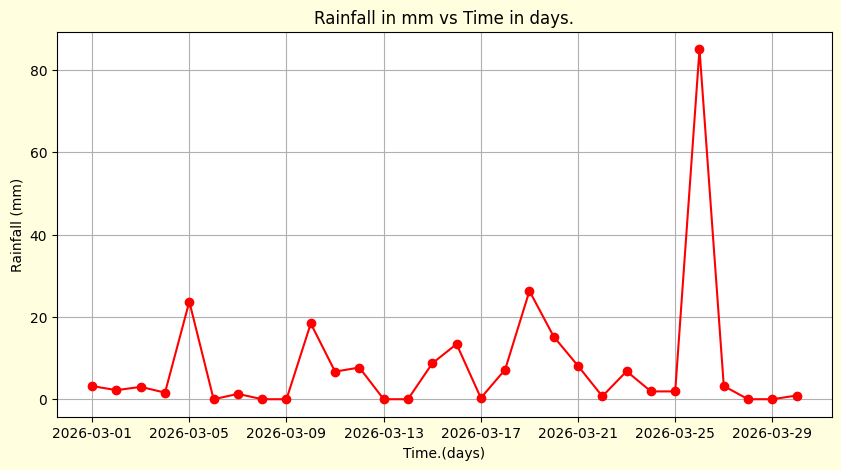

In [ ]:
#plotting using matplotlib.pyplot.

#first plot, rainfall vs time.
#checking the data type of rainfall_mm
print(weather['rainfall_mm'].dtype)

#converting rainfall_mm in weather to a proper datetime format.
weather['date'] =  pd.to_datetime(weather['date'])

#filling the one nan value with the mode for plotting purposes.
weather['rainfall_mm'] = weather['rainfall_mm'].fillna(weather['rainfall_mm'].mode()[0])

plt.figure(figsize=(10,5),facecolor="lightyellow")
plt.plot(weather['date'],weather['rainfall_mm'],color='red',marker='o')

plt.xlabel('Time.(days)')
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall in mm vs Time in days.")
plt.grid(True)
plt.show()

### Interpretation — Daily Rainfall

The rainfall plot reveals a highly variable pattern across the 30-day period,
which is consistent with Kenya's short rains season. The majority of days
recorded low to moderate rainfall below 10mm, with a few significant wet
events on 2026-03-05 (23.7mm), 2026-03-10 (18.4mm), 2026-03-19 (26.3mm),
and 2026-03-20 (15.2mm). The most striking observation is the extreme value
of 85mm recorded on 2026-03-26, which is highly suspicious and likely
represents either a sensor malfunction or a data entry error, as such a value
would be exceptionally rare even during heavy tropical rainfall. Several
consecutive days of zero rainfall are also visible, particularly toward the
end of the month, suggesting a dry spell that would place increasing stress
on soil moisture levels and demand irrigation intervention. The missing value
on 2026-03-08 is also noted and will need to be addressed during data
cleaning in Level 4.

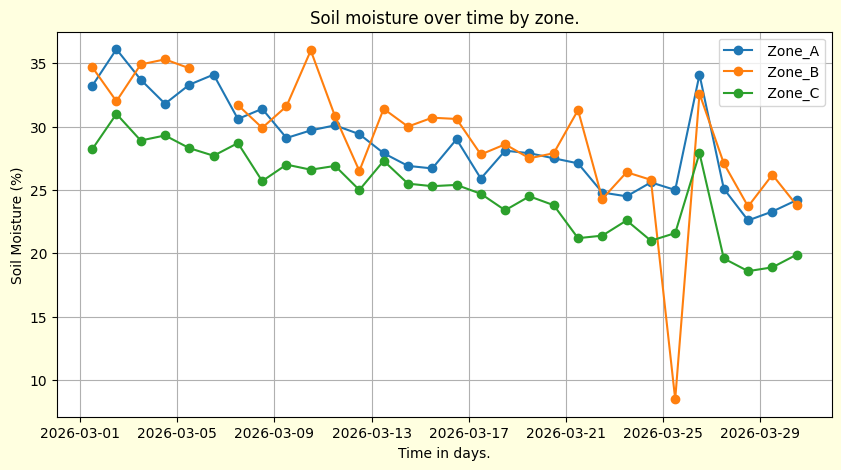

In [28]:
#second plot -> soil moisture vs time.

#converting timestamp in soil to proper datetime format.
soil['timestamp'] = pd.to_datetime(soil['timestamp'])

#the zone has three zones , so we will show this in our plot.

plt.figure(figsize=(10,5),facecolor="lightyellow")
for zone in soil['zone_id'].unique():
    zone_data = soil[soil['zone_id'] == zone]

    plt.plot(zone_data['timestamp'],
             zone_data['soil_moisture_pct'],
             marker='o',
             label=(f" {zone}"))
    
plt.xlabel('Time in days.')
plt.ylabel('Soil Moisture (%)')
plt.title('Soil moisture over time by zone.')
plt.grid(True)
plt.legend()
plt.show()

### Interpretation — Soil Moisture by Zone

The soil moisture plot shows a general declining trend across all three zones
over the 30-day period, which is consistent with the dry spell observed toward
the end of the rainfall plot. Zone_B consistently maintains the highest
moisture levels throughout the period, which aligns with its higher field
capacity of 43% and lower drainage coefficient of 0.15, meaning it retains
water more effectively. Zone_C consistently records the lowest moisture
levels, reflecting its higher drainage coefficient of 0.22 and the fact that
maize has a lower target moisture threshold than the other crops. Zone_A
sits between the two. A notable anomaly appears in Zone_B around 2026-03-25,
where soil moisture drops sharply to 8.5%, far below its minimum threshold
of 24%, which is almost certainly a sensor fault rather than a real moisture
reading and will be flagged and handled during data cleaning. The overall
declining trend across all zones toward the end of the month signals
increasing water deficit and highlights exactly the kind of situation where
a data-driven irrigation recommendation system becomes critical.

## Task 6 : Assumptions and Limitations

### Assumptions
- Soil moisture is uniform within each zone (no spatial variation considered)
- The ET formula is a simplified empirical estimate suitable for teaching purposes
- Sensor readings represent reliable daily averages unless flagged otherwise
- Rainfall is fully absorbed by the soil with no surface runoff modelled
- Irrigation is applied uniformly across the entire zone area
- The drainage coefficient is constant and does not vary with moisture level

### Limitations
- The simplified ET formula does not account for crop growth stage, 
  soil type, or advection effects
- Only 30 days of data are available, limiting seasonal analysis
- Three zones may not represent the full spatial variability of a real farm
- Missing values and sensor faults in the raw data introduce uncertainty 
  into all downstream calculations
- The water balance model treats soil as a single-layer bucket, 
  ignoring vertical moisture gradients